In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


Text(0.5, 0, 'Research Investment')

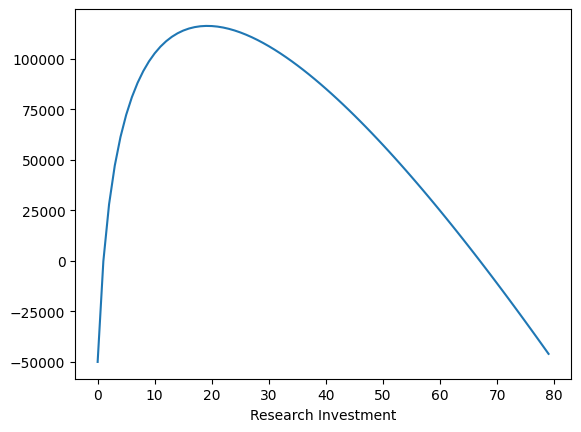

In [ ]:
TOTAL_MONEY = 50_000
USAGE = 80

def returns(research_investment, usage=USAGE, speed_factor=0.3):
    scale_investment = usage - research_investment
    research_factor = 200_000 * np.log(1 + research_investment) / np.log(1 + 100)
    
    scale_factor = scale_investment * (7/100)
    return research_factor * scale_factor * speed_factor - TOTAL_MONEY


research_investments = np.arange(0, USAGE, 1)
profits = [returns(r) for r in research_investments]
plt.plot(research_investments, profits)
plt.xlabel('Research Investment')

In [ ]:


def objective(research_investment):
    return -returns(research_investment)

result = minimize_scalar(objective)
result.x, -result.fun

(np.float64(19.21702178132752), np.float64(116307.95616480397))

In [ ]:
speed_factors = np.linspace(0.1, 0.75, 9)
usage_values = list(range(100, 0, -10))[:len(speed_factors)]


best_research_investment = []
best_returns = []

for speed_factor, usage in zip(speed_factors, usage_values):
    def objective(research_investment):
        return -returns(research_investment, speed_factor=speed_factor, usage=usage)
    
    result = minimize_scalar(objective)
    best_research_investment.append(result.x.item())
    best_returns.append(-result.fun.item())

best_research_investment, best_returns, speed_factors, usage_values

([23.140264847166613,
  21.195677144188384,
  19.21702149424067,
  17.198801508009993,
  15.133685240847718,
  13.01146606429807,
  10.817101930673521,
  8.526507430776,
  6.095789528516276],
 [24233.634733317493,
  67269.76907006941,
  95519.46164420349,
  109746.90699766367,
  110857.43838399055,
  99954.90330361837,
  78439.53210653207,
  48192.98067428,
  11986.655517889332],
 array([0.1    , 0.18125, 0.2625 , 0.34375, 0.425  , 0.50625, 0.5875 ,
        0.66875, 0.75   ]),
 [100, 90, 80, 70, 60, 50, 40, 30, 20])

In [ ]:
import pandas as pd


df = pd.DataFrame({
    'Usage': usage_values,
    '(Speed Investment)': 100 - np.array(usage_values),
    'Speed Factor': speed_factors,
    'Best Research Investment': best_research_investment,
    'Best Returns': best_returns
})

df

,Usage,(Speed Investment),Speed Factor,Best Research Investment,Best Returns
0,100,0,0.10000,23.140265,24233.634733
1,90,10,0.18125,21.195677,67269.769070
2,80,20,0.26250,19.217021,95519.461644
3,70,30,0.34375,17.198802,109746.906998
4,60,40,0.42500,15.133685,110857.438384
5,50,50,0.50625,13.011466,99954.903304
6,40,60,0.58750,10.817102,78439.532107
7,30,70,0.66875,8.526507,48192.980674
8,20,80,0.75000,6.095790,11986.655518
